In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import FuncFormatter

PATH_CSV = r'E:\02-SQL\SQL_PROJECTS\SuperStore_Sales_Analysis_SQL\OUTPUT\CSV\loss_making_products.csv'
OUTPUT_PATH = r'E:\02-SQL\SQL_PROJECTS\SuperStore_Sales_Analysis_SQL\OUTPUT\Charts'

# IF path doesn't exist
os.makedirs(OUTPUT_PATH,exist_ok=True)

In [2]:

# ------------------------------------------------------------
# 1. Load the cleaned CSV
# ------------------------------------------------------------
df = pd.read_csv(PATH_CSV)

# Sort by total_sales descending for consistency
df = df.sort_values('total_sales', ascending=False).reset_index(drop=True)

print(df.head(10))
print("Total revenue:", df['total_sales'].sum())
print("Total profit: ", df['total_profit'].sum())

          category sub_category  total_sales  total_profit  avg_profit
0       Technology       Phones    660014.20      89032.50       50.07
1        Furniture       Chairs    656898.26      53180.30       43.10
2  Office Supplies      Storage    447687.18      42558.10       25.15
3        Furniture       Tables    413931.36     -35451.18      -55.57
4  Office Supplies      Binders    406825.54      60443.28       19.84
5       Technology     Machines    378477.36       6769.46       29.43
6       Technology  Accessories    334760.62      83873.56       54.11
7       Technology      Copiers    299056.02     111235.80      817.91
8        Furniture    Bookcases    229760.10      -6945.12      -15.23
9  Office Supplies   Appliances    215064.28      36276.14       38.92
Total revenue: 4594402.14
Total profit:  572795.5800000001


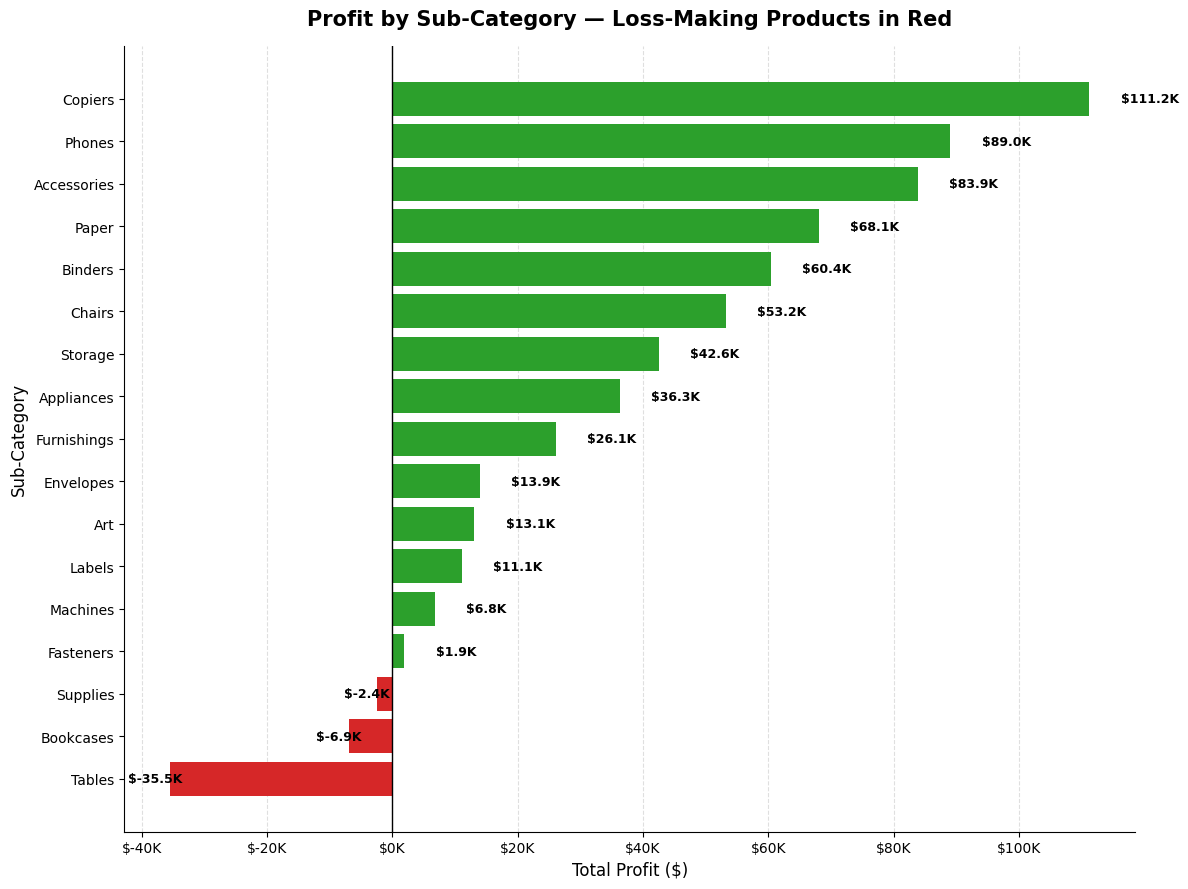

In [3]:
#CHART 2: Sub-Categories by Profit (Red = Loss)
# ============================================================
profit_sorted = df.sort_values('total_profit', ascending=True)

colors = ['#d62728' if x < 0 else '#2ca02c' for x in profit_sorted['total_profit']]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(profit_sorted['sub_category'], profit_sorted['total_profit'], color=colors)

ax.axvline(0, color='black', linewidth=1)

for bar, value in zip(bars, profit_sorted['total_profit']):
    label_x = value + 2000 if value < 0 else value + 5000
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f'${value/1_000:.1f}K',
            va='center', ha='right' if value < 0 else 'left',
            fontsize=9, fontweight='bold')

ax.set_title('Profit by Sub-Category — Loss-Making Products in Red',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Profit ($)', fontsize=12)
ax.set_ylabel('Sub-Category', fontsize=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1_000:.0f}K'))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH,'subcategory_loss_highlighted.png'), dpi=150, bbox_inches='tight')
plt.show()
